<a href="https://colab.research.google.com/github/poojithasiliveri2345-cmd/poojitha-Decision-tree/blob/main/car_price_prediction_new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#import libraries
import datetime
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df= pd.read_csv("/content/car_price.csv")
print(df.shape)

(6019, 14)


In [ ]:
#load the data
data = pd.read_csv("/content/car_price.csv")
data.head()

,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74


In [ ]:
df= pd.read_csv("/content/car_price.csv")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6019 entries, 0 to 6018
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         6019 non-null   int64  
 1   Name               6019 non-null   object 
 2   Location           6019 non-null   object 
 3   Year               6019 non-null   int64  
 4   Kilometers_Driven  6019 non-null   int64  
 5   Fuel_Type          6019 non-null   object 
 6   Transmission       6019 non-null   object 
 7   Owner_Type         6019 non-null   object 
 8   Mileage            6017 non-null   object 
 9   Engine             5983 non-null   object 
 10  Power              5983 non-null   object 
 11  Seats              5977 non-null   float64
 12  New_Price          824 non-null    object 
 13  Price              6019 non-null   float64
dtypes: float64(2), int64(3), object(9)
memory usage: 658.5+ KB
None


In [ ]:
print(df.describe())

        Unnamed: 0         Year  Kilometers_Driven        Seats        Price
count  6019.000000  6019.000000       6.019000e+03  5977.000000  6019.000000
mean   3009.000000  2013.358199       5.873838e+04     5.278735     9.479468
std    1737.679967     3.269742       9.126884e+04     0.808840    11.187917
min       0.000000  1998.000000       1.710000e+02     0.000000     0.440000
25%    1504.500000  2011.000000       3.400000e+04     5.000000     3.500000
50%    3009.000000  2014.000000       5.300000e+04     5.000000     5.640000
75%    4513.500000  2016.000000       7.300000e+04     5.000000     9.950000
max    6018.000000  2019.000000       6.500000e+06    10.000000   160.000000


In [ ]:
print(df.isnull().sum())
df=df.dropna()

Unnamed: 0              0
Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 36
Power                  36
Seats                  42
New_Price            5195
Price                   0
dtype: int64


In [ ]:

df=df.drop_duplicates()
print(df.shape)

(823, 14)


In [ ]:
#features selection
X=df[['Name','Location','Year','Kilometers_Driven','Fuel_Type','Transmission','Owner_Type','Mileage','Engine','Power','Seats']]
y=df['Price']

In [ ]:
#get current year
df=pd.read_csv("/content/car_price.csv")
current_year=datetime.datetime.now().year
df['Car_Age']=current_year-df['Year']
print(df.head())

   Unnamed: 0                              Name    Location  Year  \
0           0            Maruti Wagon R LXI CNG      Mumbai  2010   
1           1  Hyundai Creta 1.6 CRDi SX Option        Pune  2015   
2           2                      Honda Jazz V     Chennai  2011   
3           3                 Maruti Ertiga VDI     Chennai  2012   
4           4   Audi A4 New 2.0 TDI Multitronic  Coimbatore  2013   

   Kilometers_Driven Fuel_Type Transmission Owner_Type     Mileage   Engine  \
0              72000       CNG       Manual      First  26.6 km/kg   998 CC   
1              41000    Diesel       Manual      First  19.67 kmpl  1582 CC   
2              46000    Petrol       Manual      First   18.2 kmpl  1199 CC   
3              87000    Diesel       Manual      First  20.77 kmpl  1248 CC   
4              40670    Diesel    Automatic     Second   15.2 kmpl  1968 CC   

       Power  Seats  New_Price  Price  Car_Age  
0  58.16 bhp    5.0        NaN   1.75       16  
1  126.2 bhp

In [ ]:
#name unique values with label encoder
from sklearn.preprocessing import LabelEncoder
df=pd.read_csv("/content/car_price.csv")
ordinal_encoder=LabelEncoder()

df['Name']=ordinal_encoder.fit_transform(df['Name'])
print(df['Name'].unique())

[1200  512  486 ... 1830 1562  932]


In [ ]:
#extract the first word from the 'Name' column
df['Brand']=df['Name'].str.split(' ').str[0]

In [ ]:
df=df.drop(columns=['Name'])
print(df.head())

   Unnamed: 0    Location  Year  Kilometers_Driven Fuel_Type Transmission  \
0           0      Mumbai  2010              72000       CNG       Manual   
1           1        Pune  2015              41000    Diesel       Manual   
2           2     Chennai  2011              46000    Petrol       Manual   
3           3     Chennai  2012              87000    Diesel       Manual   
4           4  Coimbatore  2013              40670    Diesel    Automatic   

  Owner_Type     Mileage   Engine      Power  Seats  Price    Brand  
0      First  26.6 km/kg   998 CC  58.16 bhp    5.0   1.75   Maruti  
1      First  19.67 kmpl  1582 CC  126.2 bhp    5.0  12.50  Hyundai  
2      First   18.2 kmpl  1199 CC   88.7 bhp    5.0   4.50    Honda  
3      First  20.77 kmpl  1248 CC  88.76 bhp    7.0   6.00   Maruti  
4     Second   15.2 kmpl  1968 CC  140.8 bhp    5.0  17.74     Audi  


In [ ]:
#checking unique values in Transmition column
df= pd.read_csv("/content/car_price.csv")
print(df['Transmission'].unique())

['Manual' 'Automatic']


In [ ]:
#converting Transmission column to binary values
df=pd.read_csv("/content/car_price.csv")

df['Brand']=df['Name'].str.split(' ').str[0]

df=df.drop(columns=['Name'])

df['Transmission']=df['Transmission'].replace(('Manual','Automatic'),(0,1))
print(df.head())

   Unnamed: 0    Location  Year  Kilometers_Driven Fuel_Type  Transmission  \
0           0      Mumbai  2010              72000       CNG             0   
1           1        Pune  2015              41000    Diesel             0   
2           2     Chennai  2011              46000    Petrol             0   
3           3     Chennai  2012              87000    Diesel             0   
4           4  Coimbatore  2013              40670    Diesel             1   

  Owner_Type     Mileage   Engine      Power  Seats  New_Price  Price    Brand  
0      First  26.6 km/kg   998 CC  58.16 bhp    5.0        NaN   1.75   Maruti  
1      First  19.67 kmpl  1582 CC  126.2 bhp    5.0        NaN  12.50  Hyundai  
2      First   18.2 kmpl  1199 CC   88.7 bhp    5.0  8.61 Lakh   4.50    Honda  
3      First  20.77 kmpl  1248 CC  88.76 bhp    7.0        NaN   6.00   Maruti  
4     Second   15.2 kmpl  1968 CC  140.8 bhp    5.0        NaN  17.74     Audi  


/tmp/ipykernel_745/4064839341.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Transmission']=df['Transmission'].replace(('Manual','Automatic'),(0,1))


In [ ]:
#checking unique values Fuel_Type column
df=pd.read_csv("/content/car_price.csv")
print(df['Fuel_Type'].unique())

['CNG' 'Diesel' 'Petrol' 'LPG' 'Electric']


In [ ]:
#replacing fuel type column values to numercal values
df=pd.read_csv("/content/car_price.csv")
df['Brand']=df['Name'].str.split(' ').str[0]
df=df.drop(columns=['Name'])

df['Fuel_Type']=df['Fuel_Type'].replace(('Petrol','Diesel','CNG','LPG'),(0,1,2,3))
print(df.head(10))

   Unnamed: 0    Location  Year  Kilometers_Driven Fuel_Type Transmission  \
0           0      Mumbai  2010              72000         2       Manual   
1           1        Pune  2015              41000         1       Manual   
2           2     Chennai  2011              46000         0       Manual   
3           3     Chennai  2012              87000         1       Manual   
4           4  Coimbatore  2013              40670         1    Automatic   
5           5   Hyderabad  2012              75000         3       Manual   
6           6      Jaipur  2013              86999         1       Manual   
7           7      Mumbai  2016              36000         1    Automatic   
8           8        Pune  2013              64430         1       Manual   
9           9     Chennai  2012              65932         1       Manual   

  Owner_Type     Mileage   Engine      Power  Seats  New_Price  Price  \
0      First  26.6 km/kg   998 CC  58.16 bhp    5.0        NaN   1.75   
1     

In [ ]:
#replacing fuel type column values to numercal values
df=pd.read_csv("/content/car_price.csv")
df['Brand']=df['Name'].str.split(' ').str[0]
df=df.drop(columns=['Name'])
df['Fuel_Type']=df['Fuel_Type'].replace(('Petrol','Diesel','CNG','LPG','Electric'),(0,1,2,3,4))
print(df.tail())

      Unnamed: 0   Location  Year  Kilometers_Driven  Fuel_Type Transmission  \
6014        6014      Delhi  2014              27365          1       Manual   
6015        6015     Jaipur  2015             100000          1       Manual   
6016        6016     Jaipur  2012              55000          1       Manual   
6017        6017    Kolkata  2013              46000          0       Manual   
6018        6018  Hyderabad  2011              47000          1       Manual   

     Owner_Type     Mileage   Engine     Power  Seats  New_Price  Price  \
6014      First   28.4 kmpl  1248 CC    74 bhp    5.0  7.88 Lakh   4.75   
6015      First   24.4 kmpl  1120 CC    71 bhp    5.0        NaN   4.00   
6016     Second   14.0 kmpl  2498 CC   112 bhp    8.0        NaN   2.90   
6017      First   18.9 kmpl   998 CC  67.1 bhp    5.0        NaN   2.65   
6018      First  25.44 kmpl   936 CC  57.6 bhp    5.0        NaN   2.50   

          Brand  
6014     Maruti  
6015    Hyundai  
6016   Mahindr

/tmp/ipykernel_745/278396032.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Fuel_Type']=df['Fuel_Type'].replace(('Petrol','Diesel','CNG','LPG','Electric'),(0,1,2,3,4))


In [ ]:
##checking unique value in owner_type column
df=pd.read_csv("/content/car_price.csv")
print(df['Owner_Type'].unique())


['First' 'Second' 'Fourth & Above' 'Third']


In [ ]:
from sklearn.preprocessing import LabelEncoder
df=pd.read_csv("/content/car_price.csv")
ordinal_encoder=LabelEncoder()

df['Name']=ordinal_encoder.fit_transform(df['Name'])
print(df['Name'].unique())

[1200  512  486 ... 1830 1562  932]


In [ ]:
df=pd.read_csv("/content/car_price.csv")
ordinal_encoder=LabelEncoder()
df['Owner_Type']=ordinal_encoder.fit_transform(df['Owner_Type'])
print(df['Owner_Type'].unique())



[0 2 1 3]


In [ ]:
df=pd.read_csv("/content/car_price.csv")
print(df['Name'].unique())


['Maruti Wagon R LXI CNG' 'Hyundai Creta 1.6 CRDi SX Option'
 'Honda Jazz V' ... 'Volkswagen Polo IPL II 1.2 Petrol Highline'
 'Tata Bolt Revotron XT' 'Mahindra Xylo D4 BSIV']


In [ ]:
print(df.isnull().sum())

Unnamed: 0              0
Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 36
Power                  36
Seats                  42
New_Price            5195
Price                   0
dtype: int64


Text(0, 0.5, 'Price')

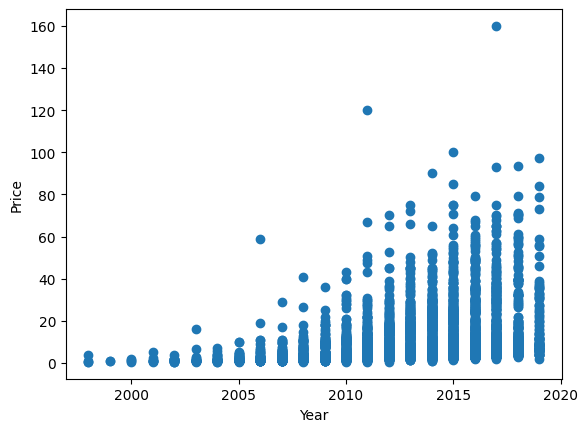

In [ ]:
from pandas.tseries.offsets import YearBegin
plt.scatter(df['Year'],df['Price'])
plt.xlabel('Year')
plt.ylabel('Price')